In [18]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
from scipy.ndimage import maximum_filter


In [3]:
audio_path = "songs/EppadiVandhaayo.mp3"  # change to your file

y, sr = librosa.load(audio_path, sr=None, mono=False)

print("Original Sample Rate:", sr)
print("Audio shape:", y.shape)


Original Sample Rate: 44100
Audio shape: (2, 7461888)


[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


In [5]:
if y.ndim == 2:
    y_mono = np.mean(y, axis=0)
else:
    y_mono = y

print("Mono shape:", y_mono.shape)



Mono shape: (7461888,)


In [ ]:
TARGET_SR = 22050

if sr != TARGET_SR:
    y_mono = librosa.resample(y_mono, orig_sr=sr, target_sr=TARGET_SR)
    sr = TARGET_SR
    print("Resampled from", sr, "to", TARGET_SR)


22050
Resampled Sample Rate: 22050


Mic distance changes the loudness
Volume does not affect the fingerprints
peak detection matters

In [9]:
y_norm = y_mono / np.max(np.abs(y_mono))

print("Max amplitude after normalization:", np.max(np.abs(y_norm)))


Max amplitude after normalization: 1.0


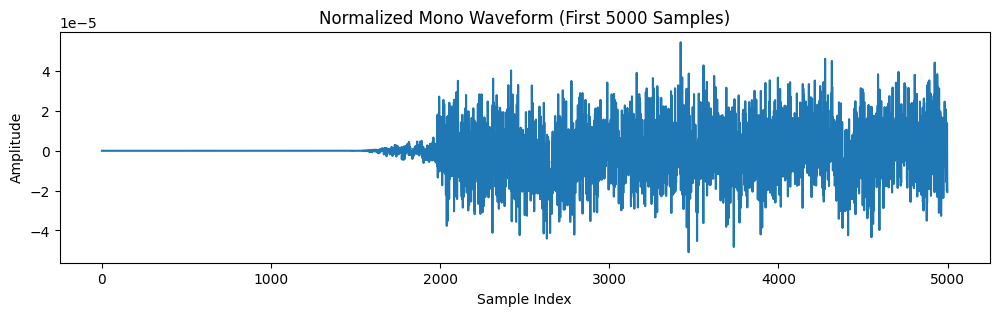

In [10]:
plt.figure(figsize=(12, 3))
plt.plot(y_norm[:5000])
plt.title("Normalized Mono Waveform (First 5000 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()


In [13]:
n_fft = 1024
hop_length = 256

S_complex = librosa.stft(
    y_norm,
    n_fft=n_fft,
    hop_length=hop_length,
    window="hann"
)
S_mag = np.abs(S_complex)
print("Spectrogram shape:", S_mag.shape)


Spectrogram shape: (513, 14575)


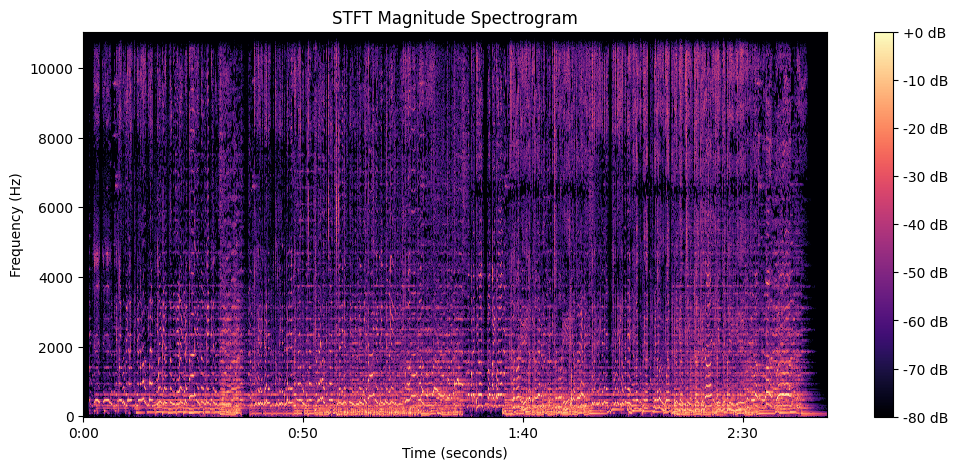

In [16]:
S_db = librosa.amplitude_to_db(S_mag, ref=np.max)
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("STFT Magnitude Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()


In [19]:
S_log = np.log1p(S_mag)
freq_neighborhood = 15
time_neighborhood = 15

local_max = maximum_filter(
    S_log,
    size=(freq_neighborhood, time_neighborhood)
)

peaks_mask = (S_log == local_max)


In [20]:
threshold = np.percentile(S_log, 75)  # top 25% energy
peaks_mask &= (S_log >= threshold)


In [21]:
peak_freqs, peak_times = np.where(peaks_mask)

print("Number of peaks detected:", len(peak_freqs))


Number of peaks detected: 17782


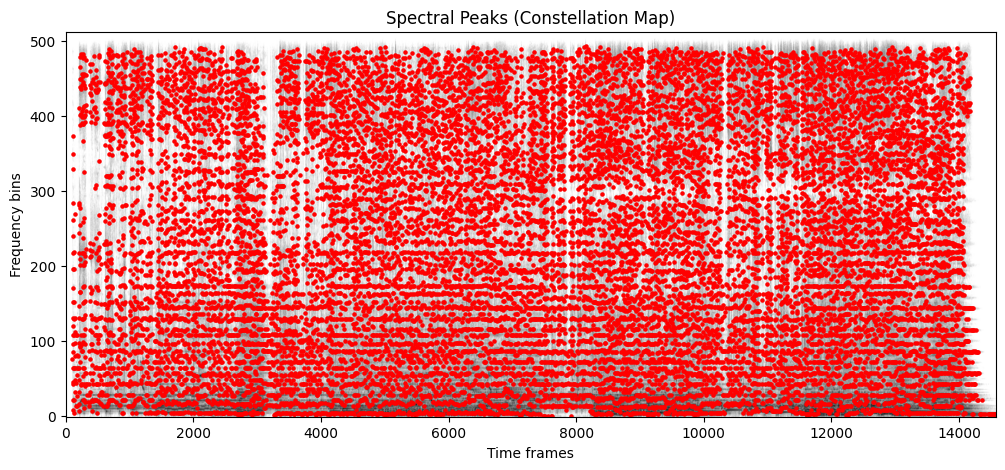

In [22]:
plt.figure(figsize=(12, 5))
plt.imshow(
    librosa.amplitude_to_db(S_mag, ref=np.max),
    origin="lower",
    aspect="auto",
    cmap="gray_r"
)
plt.scatter(peak_times, peak_freqs, c="red", s=5)
plt.title("Spectral Peaks (Constellation Map)")
plt.xlabel("Time frames")
plt.ylabel("Frequency bins")
plt.show()


In [24]:
peaks = list(zip(peak_freqs, peak_times))
peaks.sort(key=lambda x: x[1])  # sort by time

FAN_OUT = 5          # how many targets per anchor
MIN_TIME_DELTA = 1   # frames
MAX_TIME_DELTA = 50  # frames (~0.6 sec with hop=256, sr=22050)



In [23]:
import hashlib

def generate_hash(f1, f2, dt):
    """
    Generate a compact fingerprint hash
    """
    s = f"{f1}|{f2}|{dt}"
    return hashlib.sha1(s.encode("utf-8")).hexdigest()[:20]


In [25]:
fingerprints = []

for i in range(len(peaks)):
    anchor_freq, anchor_time = peaks[i]

    for j in range(1, FAN_OUT + 1):
        if i + j >= len(peaks):
            break

        target_freq, target_time = peaks[i + j]
        delta_t = target_time - anchor_time

        if MIN_TIME_DELTA <= delta_t <= MAX_TIME_DELTA:
            h = generate_hash(anchor_freq, target_freq, delta_t)
            fingerprints.append((h, anchor_time))
print("Total fingerprints generated:", len(fingerprints))
print("Sample fingerprints:")
fingerprints[:5]


Total fingerprints generated: 68740
Sample fingerprints:


[('b7218001ca4f1753264d', np.int64(106)),
 ('a608875d8ce0d6aebb7c', np.int64(106)),
 ('a5828d973b012f6398af', np.int64(106)),
 ('66617c9ef3f2dbe94f25', np.int64(106)),
 ('4bf67783bcd6d926c71a', np.int64(106))]